<a href="https://colab.research.google.com/github/Meenarekha/Computer-Vision/blob/main/IMAGE_Processing_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== COLOR IMAGE ENHANCEMENT ===


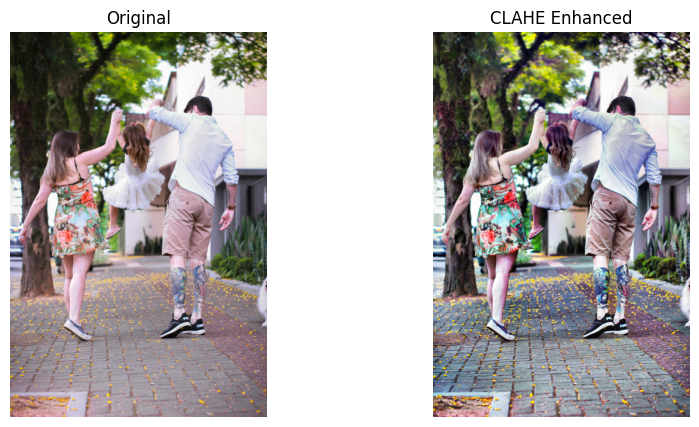

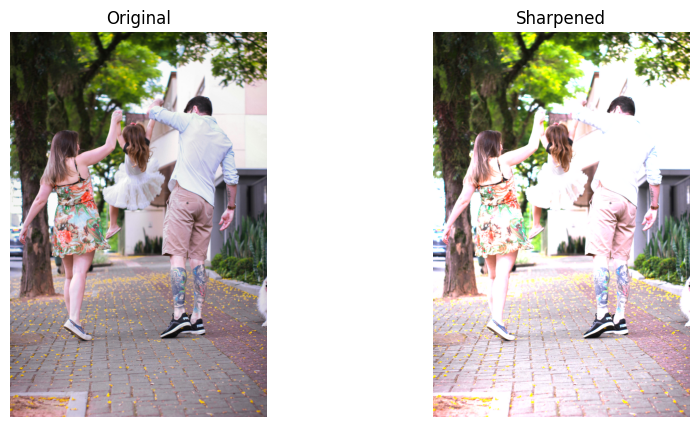

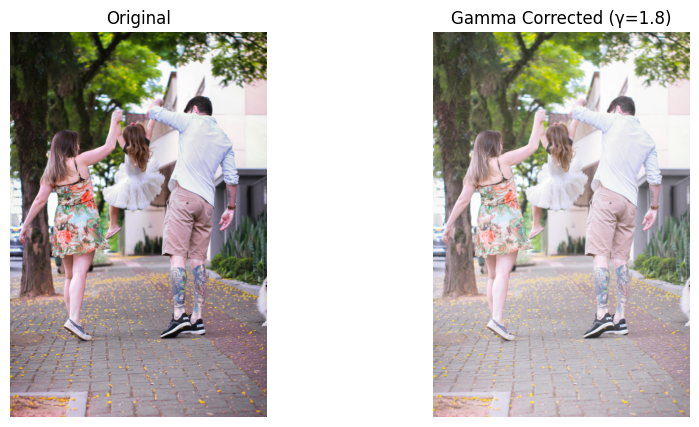

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread(r'/content/36.jpg')
if img is None:
    raise FileNotFoundError("Image '36.jpg' not found. Upload to Colab first!")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for display

# 1. CLAHE on each RGB channel
def clahe_rgb(img_rgb):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    channels = cv2.split(img_rgb)
    enhanced_channels = [clahe.apply(ch) for ch in channels]
    enhanced = cv2.merge(enhanced_channels)

    plt.figure(figsize=(10,5))
    plt.subplot(121), plt.imshow(img_rgb), plt.title('Original')
    plt.axis("off")
    plt.subplot(122), plt.imshow(enhanced), plt.title('CLAHE Enhanced')
    plt.axis("off")
    plt.show()


# 2. Unsharp Masking (Color-preserving)
def unsharp_rgb(img_rgb):
    blurred = cv2.GaussianBlur(img_rgb, (5,5), 2)
    sharpened = cv2.addWeighted(img_rgb, 2, blurred, -0.5, 0)

    plt.figure(figsize=(10,5))
    plt.subplot(121), plt.imshow(img_rgb), plt.title('Original')
    plt.axis("off")
    plt.subplot(122), plt.imshow(sharpened), plt.title('Sharpened')
    plt.axis("off")
    plt.show()


# 3. Gamma Correction (Color-preserving)
def gamma_rgb(img_rgb, gamma=1.5):
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    corrected = cv2.LUT(img_rgb, table)

    plt.figure(figsize=(10,5))
    plt.subplot(121), plt.imshow(img_rgb), plt.title('Original')
    plt.axis("off")
    plt.subplot(122), plt.imshow(corrected), plt.title(f'Gamma Corrected (γ={gamma})')
    plt.axis("off")
    plt.show()


# Execute all enhancements
print("=== COLOR IMAGE ENHANCEMENT ===")
clahe_rgb(img_rgb)
unsharp_rgb(img_rgb)
gamma_rgb(img_rgb, gamma=1.8)

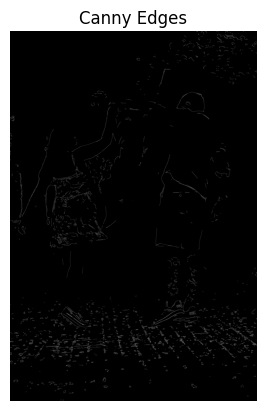

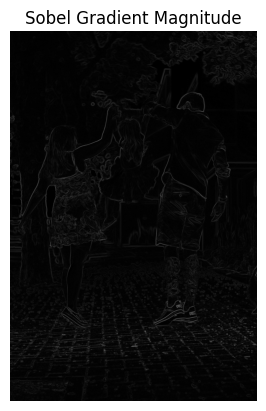

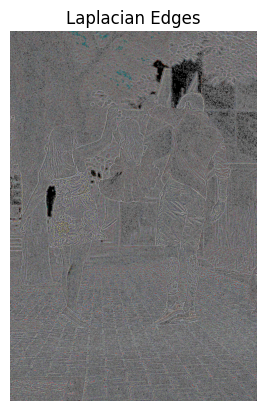

In [ ]:

# 1. Canny Edge Detection
canny = cv2.Canny(img, 100, 200)
plt.imshow(canny, cmap='gray'), plt.title('Canny Edges')
plt.axis("off")
plt.show()


# 2. Sobel Operator
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)
sobel = cv2.magnitude(sobelx, sobely)
plt.imshow(sobel, cmap='gray'); plt.title("Sobel Gradient Magnitude"); plt.axis("off")
plt.show()


# 3. Laplacian Edge Detection
laplacian = cv2.Laplacian(img, cv2.CV_64F)
plt.imshow(laplacian, cmap='gray'), plt.title('Laplacian Edges')
plt.axis("off")
plt.show()


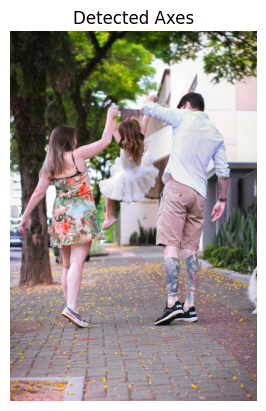

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r'/content/36.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Canny edge detection
edges = cv2.Canny(gray, 50, 150)

# Hough Line Transform
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=50,
                        minLineLength=100, maxLineGap=10)

# Draw lines
result = img.copy()
for line in lines:
    x1,y1,x2,y2 = line[0]
    cv2.line(result, (x1,y1), (x2,y2), (0,0,255), 2)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title('Detected Axes'), plt.axis('off')
plt.show()

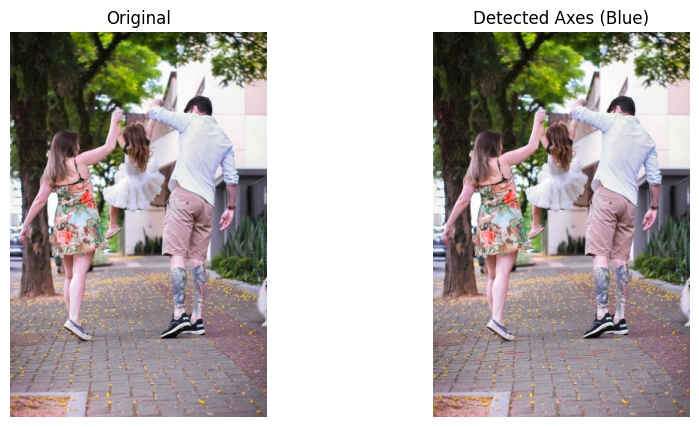

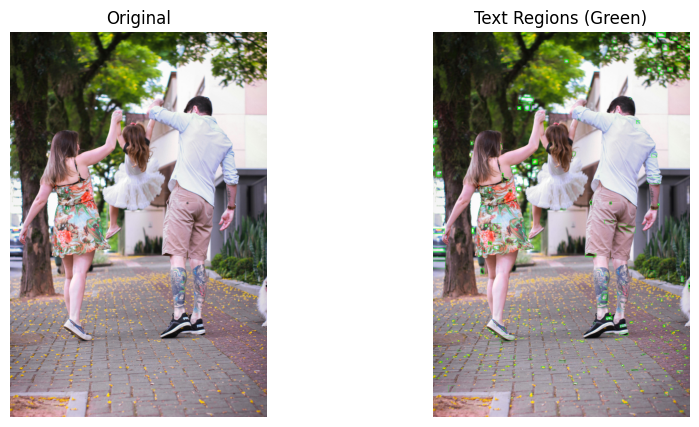

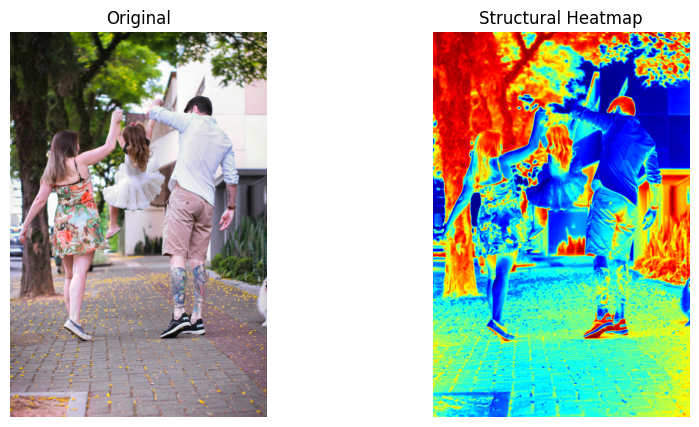

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

# Load image
img = cv2.imread(r'/content/36.jpg')
if img is None:
    raise FileNotFoundError("Image '36.jpg' not found. Please upload it first!")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 1. Axis Line Detection with Hough Transform (Best for your image)
edges = cv2.Canny(gray, 50, 150)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=50,
                       minLineLength=100, maxLineGap=10)

axis_img = img_rgb.copy()
for line in lines:
    x1,y1,x2,y2 = line[0]
    angle = np.degrees(np.arctan2(y2-y1, x2-x1))
    # Filter near-vertical/horizontal lines
    if abs(angle) < 10 or abs(angle-90) < 10:
        cv2.line(axis_img, (x1,y1), (x2,y2), (255,0,0), 2)

plt.figure(figsize=(10,5))
plt.subplot(121), plt.imshow(img_rgb), plt.title('Original'), plt.axis('off')
plt.subplot(122), plt.imshow(axis_img), plt.title('Detected Axes (Blue)'), plt.axis('off')
plt.show()

# 2. Text Region Detection using MSER
mser = cv2.MSER_create()
regions, _ = mser.detectRegions(gray)
text_img = img_rgb.copy()
for region in regions:
    x,y,w,h = cv2.boundingRect(region.reshape(-1,1,2))
    if 10 < w < 200 and 10 < h < 100:  # Filter by expected text size
        cv2.rectangle(text_img, (x,y), (x+w,y+h), (0,255,0), 1)

plt.figure(figsize=(10,5))
plt.subplot(121), plt.imshow(img_rgb), plt.title('Original'), plt.axis('off')
plt.subplot(122), plt.imshow(text_img), plt.title('Text Regions (Green)'), plt.axis('off')
plt.show()

# 3. Structural Heatmap
blur = cv2.GaussianBlur(gray, (25,25), 0)
heatmap = cv2.normalize(blur, None, 0, 255, cv2.NORM_MINMAX)
heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

plt.figure(figsize=(10,5))
plt.subplot(121), plt.imshow(img_rgb), plt.title('Original'), plt.axis('off')
plt.subplot(122), plt.imshow(heatmap_colored), plt.title('Structural Heatmap'), plt.axis('off')
plt.show()

In [ ]:
!pip install ultralytics


image 1/1 /content/36.jpg: 640x448 3 persons, 1 car, 139.4ms
Speed: 3.8ms preprocess, 139.4ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 448)


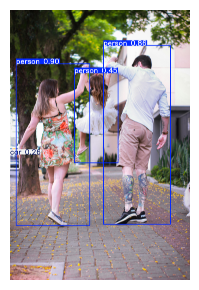


Compact Results:
- person: Confidence 0.90
- person: Confidence 0.86
- person: Confidence 0.45
- car: Confidence 0.26


In [ ]:
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
results = model('/content/36.jpg', imgsz=640)

# Mini visualization
plt.figure(figsize=(5,3))
plt.imshow(results[0].plot()[:,:,::-1])
plt.axis('off')
plt.tight_layout()
plt.show()

# Text-only results
print("\nCompact Results:")
for box in results[0].boxes:
    class_id = int(box.cls)
    conf = float(box.conf)
    print(f"- {results[0].names[class_id]}: Confidence {conf:.2f}")

In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import os

# Define a dummy model or replace this with your trained object detection model
class DummyModel(tf.Module):
    @tf.function(input_signature=[tf.TensorSpec(shape=[None, None, None, 3], dtype=tf.uint8)])
    def __call__(self, x):
        # Dummy detection output
        return {
            'detection_classes': tf.constant([[[1, 3, 2]]], dtype=tf.int32)  # Pretend we detect classes
        }

# Initialize and save the dummy model (replace this with your real model)
model = DummyModel()

# Specify the directory where you want to save the model
model_path = "/content/my_saved_model"
os.makedirs(model_path, exist_ok=True)
tf.saved_model.save(model, model_path)

# Load image from disk and convert to RGB
def load_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Load model from saved directory
loaded_model = tf.saved_model.load(model_path)

def detect_objects(image):
    input_tensor = tf.convert_to_tensor(image)
    input_tensor = input_tensor[tf.newaxis, ...]  # Add batch dimension
    detections = loaded_model(input_tensor)
    return detections

def analyze_activity(detections):
    activities = []
    if 'detection_classes' in detections:
        detected_classes = detections['detection_classes'][0].numpy()
        for detection in detected_classes:
            # Check if any element in the detection is equal to 1
            if 1 in detection:  # Changed line
                activities.append("Person detected")
    else:
        activities.append("No detections found")
    return activities

def context_understanding(image):
    # Placeholder scene analysis
    return "Outdoor scene with family activities"

def main(image_path):
    image = load_image(image_path)
    detections = detect_objects(image)
    activities = analyze_activity(detections)
    scene_context = context_understanding(image)

    print("Activities Detected:", activities)
    print("Scene Context:", scene_context)

# Run the main function with your image path
main("/content/36.jpg")


Activities Detected: ['Person detected']
Scene Context: Outdoor scene with family activities


Device set to use cpu


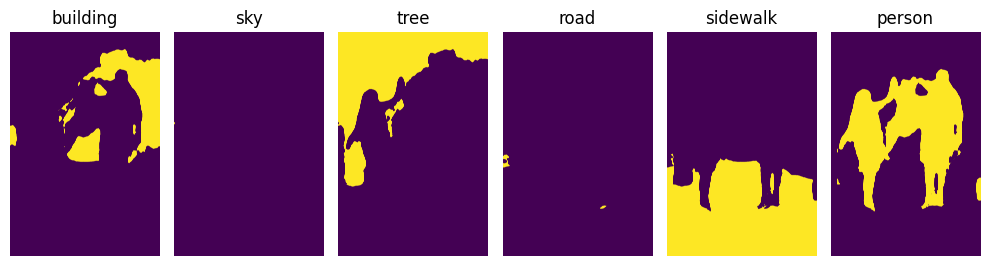

In [ ]:
import matplotlib.pyplot as plt
from transformers import pipeline
from PIL import Image

seg = pipeline("image-segmentation", model="nvidia/segformer-b0-finetuned-ade-512-512")

def segment_diagram(img_path):
    # Load the image using PIL
    image = Image.open(img_path)

    # Perform segmentation using the loaded image instead of the path
    results = seg(image)

    # Visualize
    plt.figure(figsize=(10,5))
    for i, res in enumerate(results[:6]):  # Show top 3 segments
        plt.subplot(1,6,i+1)
        plt.imshow(res['mask'])
        plt.title(res['label']), plt.axis('off')
    plt.tight_layout()
    plt.show()

    return results

segmentation_results = segment_diagram('/content/36.jpg')